<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0f7a7a; overflow:hidden"><b>Preprocessing of NLP 

</b></div>

# Dataset link imdb 
https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

<div style="padding:10px;color:white;margin:0;font-size:200%;text-align:center;display:fill;border-radius:10px;background-color:#215f95;;overflow:hidden;font-weight:501;font-family:magra">Read data</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
# Initialize tqdm with pandas
tqdm.pandas()

In [7]:
import os
os.chdir(r'C:\Users\Admin\Documents\Digilians\Second Term\AI-202 Natural Language Processing\Sections\Lab 1')

In [8]:
df=pd.read_csv('IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [9]:
df.shape

(10000, 2)

In [10]:
df['review'][100].lower()

"this short film that inspired the soon-to-be full length feature - spatula madness - is a hilarious piece that contends against similar cartoons yielding multiple writers. the short film stars edward the spatula who after being fired from his job, joins in the fight against the evil spoons. this premise allows for some funny content near the beginning, but is barely present for the remainder of the feature. this film's 15-minute running time is absorbed by some odd-ball comedy and a small musical number. unfortunately not much else lies below it. the plot that is set up doesn't really have time to show. but it's surely follows it plot better than many high-budget hollywood films. this film is worth watching at least a few times. take it for what it is, and don't expect a deep story."

In [11]:
df['review']=df['review'].str.lower()
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


<Axes: xlabel='sentiment', ylabel='count'>

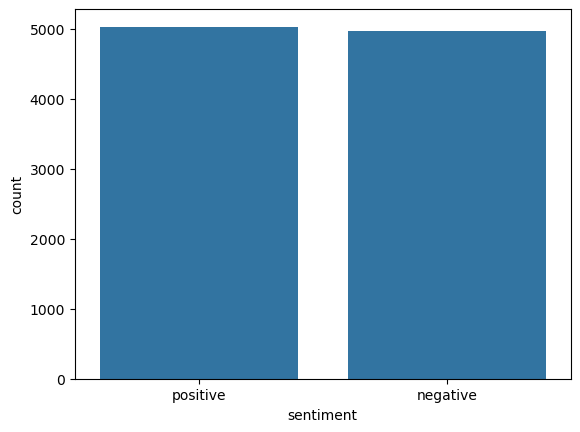

In [12]:
sns.countplot(data=df,x='sentiment')

<div style="padding:10px;color:white;margin:0;font-size:200%;text-align:center;display:fill;border-radius:10px;background-color:#215f95;;overflow:hidden;font-weight:501;font-family:magra">Remove html tags using Regular expressions</div>

In [13]:
import re
def remove_html_tags(text):
    pattern = re.compile('<.*?>')
    return pattern.sub('', text)

In [14]:
df['review']=df['review'].progress_apply(lambda x : remove_html_tags(x))
df.head()

100%|████████████████████████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 218963.11it/s]


,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


<div style="padding:10px;color:white;margin:0;font-size:200%;text-align:center;display:fill;border-radius:10px;background-color:#215f95;;overflow:hidden;font-weight:501;font-family:magra">Removing URLs</div>

In [15]:
def remove_url(text):
    pattern=re.compile(r'https?://\S+|www\.\S+')
    return pattern.sub(r'',text)

df['review']=df['review'].progress_apply(lambda x : remove_url(x))
df.head()

100%|█████████████████████████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 93196.81it/s]


,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive



<div style="padding:10px;color:white;margin:0;font-size:200%;text-align:center;display:fill;border-radius:10px;background-color:#215f95;;overflow:hidden;font-weight:501;font-family:magra">Handling emojis</div>

In [16]:
# pip install emoji
import emoji

df['review'] = df['review'].progress_apply(emoji.demojize)
df.head()

ModuleNotFoundError: No module named 'emoji'


<div style="padding:10px;color:white;margin:0;font-size:200%;text-align:center;display:fill;border-radius:10px;background-color:#215f95;;overflow:hidden;font-weight:501;font-family:magra">Remove digits</div>

In [ ]:
# Define a function to remove digits
def remove_digits(text):
    
    return re.sub(r'\d+', '', text)

df['review'] = df['review'].progress_apply(lambda x: remove_digits(x))
df.head()

100%|██████████| 10000/10000 [00:00<00:00, 25680.72it/s]


,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive



<div style="padding:10px;color:white;margin:0;font-size:200%;text-align:center;display:fill;border-radius:10px;background-color:#215f95;;overflow:hidden;font-weight:501;font-family:magra">Removing punchuation</div>

In [13]:
import string

In [14]:
exclude=string.punctuation
exclude

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

##### These are the punchuations in python

In [15]:
def remove_punc(text):
    for char in exclude:
        text=text.replace(char,'')
    return text

df['review']=df['review'].progress_apply(lambda x : remove_punc(x))
df.head()

100%|██████████| 10000/10000 [00:00<00:00, 20389.96it/s]


,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive


<div style="padding:10px;color:white;margin:0;font-size:200%;text-align:center;display:fill;border-radius:10px;background-color:#215f95;;overflow:hidden;font-weight:501;font-family:magra">Spelling correction</div>

In [76]:
#!pip install textblob
from textblob import TextBlob
def check_spelling(text):
    textblb=TextBlob(text)
    return textblb.correct().string

df['review']=df['review'].progress_apply(lambda x : check_spelling(x))
df.head()

100%|█████████████████████████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 38882.81it/s]


,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive



<div style="padding:10px;color:white;margin:0;font-size:200%;text-align:center;display:fill;border-radius:10px;background-color:#215f95;;overflow:hidden;font-weight:501;font-family:magra">Removing StopWords</div>


In [16]:
from nltk.corpus import stopwords

In [20]:
import nltk
nltk.download('stopwords', download_dir='C:/Users/MG magic/nltk_data')


[nltk_data] Downloading package stopwords to C:/Users/MG
[nltk_data]     magic/nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [21]:
StopWords = stopwords.words("english")
StopWords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [22]:
def remove_stopwords(text):
    filtered_text = ' '.join(word for word in text.split() if word.lower() not in StopWords)
    return filtered_text

df['review']=df['review'].progress_apply(lambda x : remove_stopwords(x))
df.head()

100%|██████████| 10000/10000 [00:05<00:00, 1774.81it/s]


,review,sentiment
0,one reviewers mentioned watching oz episode yo...,positive
1,wonderful little production filming technique ...,positive
2,thought wonderful way spend time hot summer we...,positive
3,basically theres family little boy jake thinks...,negative
4,petter matteis love time money visually stunni...,positive



<div style="padding:10px;color:white;margin:0;font-size:200%;text-align:center;display:fill;border-radius:10px;background-color:#215f95;;overflow:hidden;font-weight:501;font-family:magra">Split data</div>


In [31]:
X = df.drop('sentiment',axis =1)
y = df['sentiment']

In [32]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [33]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1,stratify=y)


In [34]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((8000, 1), (2000, 1), (8000,), (2000,))


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0f7a7a; overflow:hidden"><b>Bag of Words
</b></div>


<div style="padding:10px;color:white;margin:0;font-size:200%;text-align:center;display:fill;border-radius:10px;background-color:#215f95;;overflow:hidden;font-weight:501;font-family:magra">Count vectorization and N-Gram</div>


In [39]:
from sklearn.feature_extraction.text import CountVectorizer

In [40]:
vectorizer = CountVectorizer(
    lowercase=True,                  # Converts all characters to lowercase before tokenization.
    tokenizer=None,                  # the default tokenizer will be used.
    stop_words=None,                 # You can provide a list of stop words or use 'english' to remove common English stop words.
    max_features=10000,              # all tokens will be included.
    ngram_range=(1, 1),              # Use unigrams (1 word)
    vocabulary=None,                 # a vocabulary will be created from the input documents.
    binary=False                     # If False, the count of occurrences of each token is recorded; if True, only presence/absence is recorded.
)

# Transform the text data into a document-term matrix
X_tr = vectorizer.fit_transform(X_train['review'])
X_te = vectorizer.transform(X_test['review'])

In [41]:
print(vectorizer.vocabulary_)

{'friend': np.int64(3605), 'made': np.int64(5385), 'sit': np.int64(8101), 'watch': np.int64(9681), 'film': np.int64(3372), 'material': np.int64(5517), 'god': np.int64(3805), 'devil': np.int64(2429), 'heaven': np.int64(4115), 'hell': np.int64(4134), 'restaurant': np.int64(7378), 'thrown': np.int64(9021), 'good': np.int64(3825), 'guys': np.int64(3967), 'dies': np.int64(2459), 'thats': np.int64(8945), 'story': np.int64(8529), 'youll': np.int64(9974), 'never': np.int64(6002), 'guess': np.int64(3942), 'ending': np.int64(2920), 'one': np.int64(6203), 'skillfully': np.int64(8123), 'realized': np.int64(7132), 'little': np.int64(5234), 'gem': np.int64(3708), 'aussie': np.int64(601), 'cinema': np.int64(1516), 'hats': np.int64(4076), 'team': np.int64(8869), 'got': np.int64(3843), 'great': np.int64(3889), 'movie': np.int64(5840), 'loved': np.int64(5321), 'although': np.int64(276), 'jane': np.int64(4764), 'voice': np.int64(9591), 'beginning': np.int64(784), 'annoying': np.int64(366), 'dont': np.int

In [42]:
vocab = vectorizer.get_feature_names_out()
vocab

array(['aaron', 'abandon', 'abandoned', ..., 'zone', 'zoo', 'zucco'],
      shape=(10000,), dtype=object)

In [43]:
vocab.shape

(10000,)

In [44]:
X_train1 = pd.DataFrame(X_tr.toarray(), columns=vocab)

X_train1.head()

,aaron,abandon,abandoned,abandoning,abandons,abbey,abbot,abbott,abc,abe,...,zero,zhang,zip,zodiac,zoey,zombie,zombies,zone,zoo,zucco
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
X_test1 = pd.DataFrame(X_te.toarray(), columns=vocab)

X_test1.head()

,aaron,abandon,abandoned,abandoning,abandons,abbey,abbot,abbott,abc,abe,...,zero,zhang,zip,zodiac,zoey,zombie,zombies,zone,zoo,zucco
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0f7a7a; overflow:hidden"><b> Training and prediction using ML models
</b></div>

<div style="padding:10px;color:white;margin:0;font-size:200%;text-align:center;display:fill;border-radius:10px;background-color:#215f95;;overflow:hidden;font-weight:501;font-family:magra">Training with GaussianNB</div>

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()

In [52]:
gnb.fit(X_train1,y_train)
y_pred = gnb.predict(X_test1)
accuracy_score(y_test,y_pred)

0.703

<div style="padding:10px;color:white;margin:0;font-size:200%;text-align:center;display:fill;border-radius:10px;background-color:#215f95;;overflow:hidden;font-weight:501;font-family:magra">Training with Random Forest Classifier</div>

In [54]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

rf.fit(X_train1,y_train)
y_pred = rf.predict(X_test1)
accuracy_score(y_test,y_pred)

0.8345